# Lékárny v Ústeckém kraji — analýza v MongoDB a Neo4j

Řešení úlohy okruhu **NoSQL databáze** (SZZVP).

Notebook spouští dotazy nad naplněnými databázemi a vizualizuje jejich výstupy.
**Grafy vznikají z výsledků agregačních pipeline, ne z původních CSV/XLSX** —
to je požadavek zadání.

## Než tohle spustíš

```bash
docker compose up -d                                     # MongoDB + Neo4j
PYTHONPATH=src .venv/bin/python src/load_mongo.py        # naplní Mongo
PYTHONPATH=src .venv/bin/python src/load_neo4j.py        # naplní Neo4j
```

## Zdrojová data

| Zdroj | Obsah | Role v úloze |
|---|---|---|
| `lekarny_uk.csv` | 167 lékáren v ÚK (registr NRPZS) | předmět analýzy |
| `0043_Struktura uzemi CR…xlsx` | hierarchie obcí ČR, 13 ročních listů | **autoritativní** hierarchie |
| `CZ/CZ.txt` | 43 264 objektů Geonames | geometrie (souřadnice, populace) |
| `admin2Codes.txt` | 98 českých okresů Geonames | most mezi Geonames a ČSÚ |

In [1]:
import sys
from pathlib import Path

# Notebook běží v notebooks/, moduly jsou v src/ v korenu repozitáře.
# Cesta se odvozuje od umístění notebooku, aby fungovala i při
# spuštění přes nbconvert z jiného adresáře.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd

import dotazy_mongo as dm
import dotazy_neo4j as dn
import vizualizace as viz

viz.nastav_styl()
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

db = dm.pripoj()
print("MongoDB:", db.obce.count_documents({}), "obcí,",
      db.lekarny.count_documents({}), "lékáren")

MongoDB: 354 obcí, 167 lékáren


## 1. Řešení nekonzistencí

Tři zdroje používají **tři nekompatibilní kódové systémy** a jediné spolehlivé
pojivo je název:

| Zdroj | Kraj | Okres |
|---|---|---|
| ČSÚ (XLSX, registr) | `CZ042` (NUTS 3) | `CZ0426` (LAU 1) |
| Geonames | `89` (**FIPS**) | `0426` |
| admin2Codes | — | `CZ.89.0426`, **bez NUTS** |

Ošetřené případy (podrobně `src/normalize.py`, ověření `src/kontrola.py`):

- **FIPS → NUTS** převodní tabulka; bez ní by spojení tiše vracelo nula výsledků
- **Diakritika** — `norm()` přes NFKD (`Ústí` ≡ `Usti`)
- **Praha** dělená v Geonames na 22 částí → sjednoceno na `CZ0100`,
  ale Praha-východ (`CZ0209`) a Praha-západ (`CZ020A`) zůstaly samostatné
- **`Město Brno` vs. `Brno-město`** → alias
- **3 lékárny bez souřadnic** → dogeokódovány na střed obce, příznak `geo_zdroj`
- **6 duplicitních názvů obcí** → rozhodnuto podle okresu a populace, deterministicky
- **Sídlo firmy ≠ poloha lékárny** — 91 ze 167 lékáren má sídlo mimo kraj
  (41 v Brně, 25 v Praze); geokódování podle něj by je rozprostřelo po ČR
- **2 obce bez záznamu v Geonames** (Líšťany, Nezabylice) → `loc: null`,
  vyloučeny z geodotazů

Kódy okresů jsou **hexadecimální** (`0209, 020A, 020B, 020C`) — nikdy je
neparsovat jako `int`.

In [2]:
# Kvalita polohových dat — ovlivňuje spolehlivost všech vzdáleností
for r in dm.kvalita_geokodovani(db):
    obce = f"  ({', '.join(sorted(set(r['obce'])))})" if r["_id"] == "obec" else ""
    print(f"geo_zdroj={r['_id']!r:<12} {r['pocet']:>3} lékáren{obce}")

geo_zdroj='registr'    164 lékáren
geo_zdroj='obec'         3 lékáren  (Louny, Lovosice, Ústí nad Labem)


## 2. Povinná tabulka: počty lékáren v okresech a ORP

Zadání chce **obojí**, protože hranice okresů a ORP se nekryjí — okres
Litoměřice se dělí na ORP Litoměřice, Lovosice a Roudnice nad Labem.

Denormalizace se tu vyplácí: okres i ORP jsou zkopírované do každé lékárny,
takže stačí `$group` bez `$lookup`.

In [3]:
okresy = pd.DataFrame(dm.pocty_okresy(db))
okresy

,kod,okres,obci,obci_s_lekarnou,obci_bez_lekarny,lekaren,populace,lekaren_na_10tis
0,CZ0421,Děčín,52,11,41,34,126712,2.68
1,CZ0422,Chomutov,44,7,37,20,117430,1.70
2,CZ0423,Litoměřice,105,9,96,27,114647,2.36
3,CZ0424,Louny,70,6,64,13,83953,1.55
4,CZ0425,Most,26,3,23,18,107099,1.68
5,CZ0426,Teplice,34,9,25,32,125632,2.55
6,CZ0427,Ústí nad Labem,23,4,19,23,113903,2.02


In [4]:
orp = pd.DataFrame(dm.pocty_orp(db))
orp

,kod,orp,obci,obci_s_lekarnou,obci_bez_lekarny,lekaren,populace,lekaren_na_10tis
0,4201,Bílina,8,2,6,6,19180,3.13
1,4202,Děčín,34,5,29,20,73673,2.71
2,4203,Chomutov,25,3,22,13,75160,1.73
3,4204,Kadaň,19,4,15,7,42270,1.66
4,4205,Litoměřice,40,4,36,13,57972,2.24
5,4206,Litvínov,11,2,9,6,34967,1.72
6,4207,Louny,41,2,39,6,41377,1.45
7,4208,Lovosice,32,3,29,8,26222,3.05
8,4209,Most,15,1,14,12,72132,1.66
9,4210,Podbořany,11,3,8,3,15932,1.88


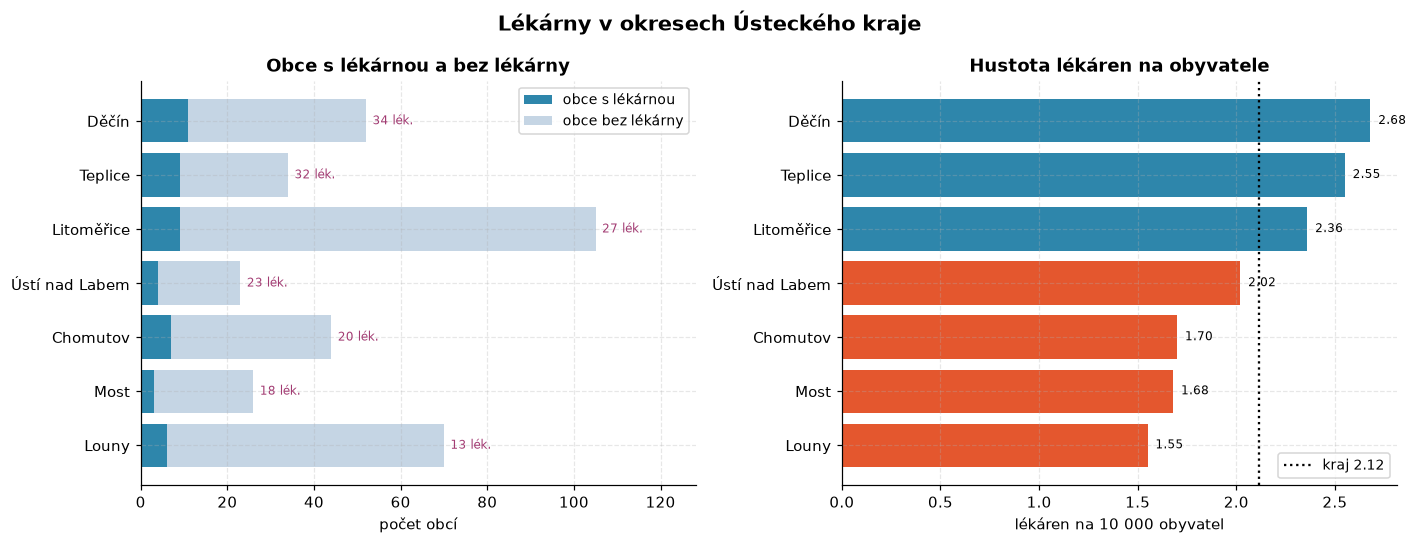

In [5]:
fig = viz.graf_okresy(db)

**Absolutní počty a hustota říkají různé věci.** Most má 18 lékáren, víc
než Louny s 13 — ale na obyvatele je Most na 1,68 a Louny na 1,55, přičemž
Most má o čtvrtinu víc obyvatel. Čtyři okresy jsou pod krajským průměrem 2,12.

Nejnápadnější je **Litoměřice: 105 obcí, ale lékárna jen v 9 z nich**.

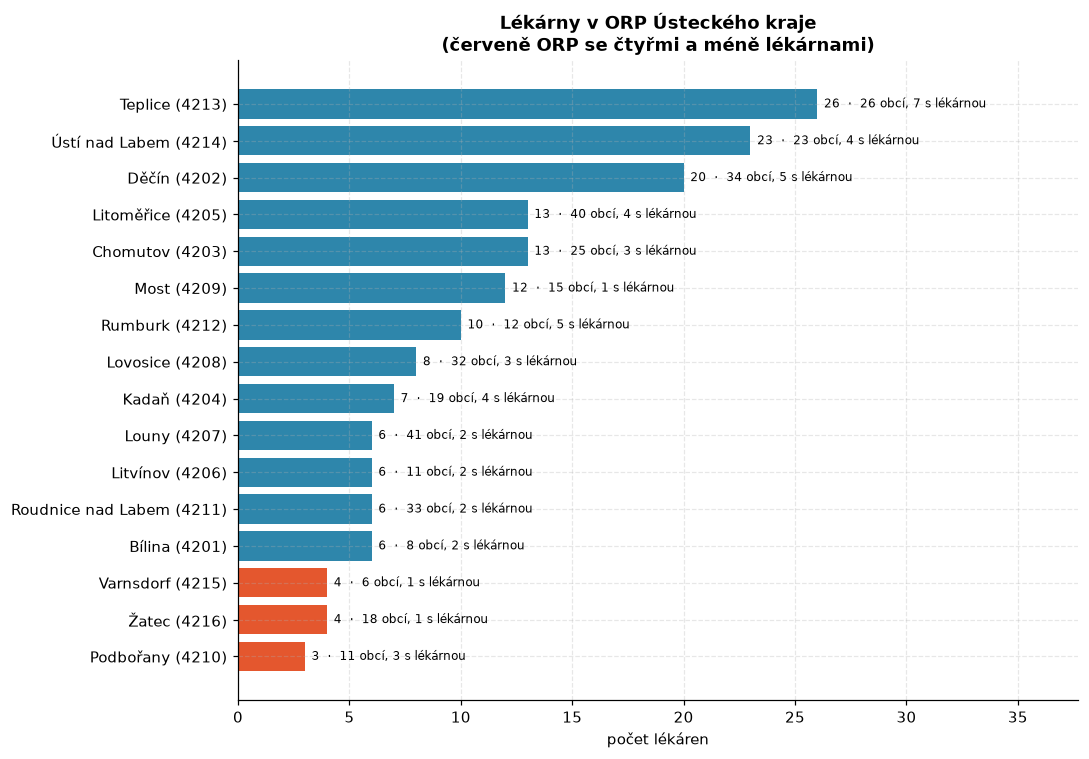

In [6]:
fig = viz.graf_orp(db)

## 3. Hlavní úloha (MongoDB): vzdálenost k nejbližší lékárně

Pro **303 obcí bez vlastní lékárny** se známou polohou.

### Jak pipeline funguje

`$geoNear` musí být **první stupeň pipeline**, ale potřebujeme ho spustit pro
každou obec zvlášť. Řešení je vnořená pipeline v `$lookup`:

```
$match    →  obce bez lékárny se známou polohou (303)
$lookup   →  pro KAŽDOU obec nad kolekcí lekarny:
                $geoNear  vzdálenosti od středu té obce
                $limit 1  jen nejbližší
$unwind   →  rozbalí jednoprvkové pole
$project  →  metry → kilometry
$sort     →  nejvzdálenější první
```

Klíč je `"let": {"stred": "$loc"}` — předá polohu nadřazené obce do vnořené
pipeline jako `$$stred`. Bez toho by úloha nešla jedním dotazem.

**Past:** MongoDB 8 zrušilo parametr `limit` uvnitř `$geoNear` (starší
tutoriály ho ještě používají) — musí následovat samostatný stupeň `$limit`.

In [7]:
souhrn = dm.souhrn_vzdalenosti(db)
for k, v in souhrn.items():
    print(f"{k:<20} {v}")

obci                 303
min_km               0.4
max_km               14.98
obyvatel_nad_5km     66788
obci_nad_5km         140
obci_nad_10km        12
prumer_km            4.99
median_km            4.82


In [8]:
top10 = pd.DataFrame(dm.nejvzdalenejsi_obce(db, 10))
top10[["obec", "okres", "orp", "populace", "km", "lekarna_v", "lekarna_retezec"]]

,obec,okres,orp,populace,km,lekarna_v,lekarna_retezec
0,Brandov,Most,Litvínov,249,14.98,Jirkov,nezávislá
1,Domoušice,Louny,Louny,622,14.05,Louny,nezávislá
2,Pnětluky,Louny,Louny,324,12.29,Postoloprty,Dr. Max
3,Kalek,Chomutov,Chomutov,170,12.15,Jirkov,nezávislá
4,Hora Svaté Kateřiny,Most,Litvínov,367,11.63,Jirkov,nezávislá
5,Hora Svatého Šebestiána,Chomutov,Chomutov,253,11.62,Chomutov,Dr. Max
6,Úherce,Louny,Louny,67,11.27,Louny,BENU
7,Ročov,Louny,Louny,572,11.01,Louny,nezávislá
8,Deštnice,Louny,Žatec,182,10.80,Žatec,Dr. Max
9,Libčeves,Louny,Louny,862,10.58,Bílina,BENU


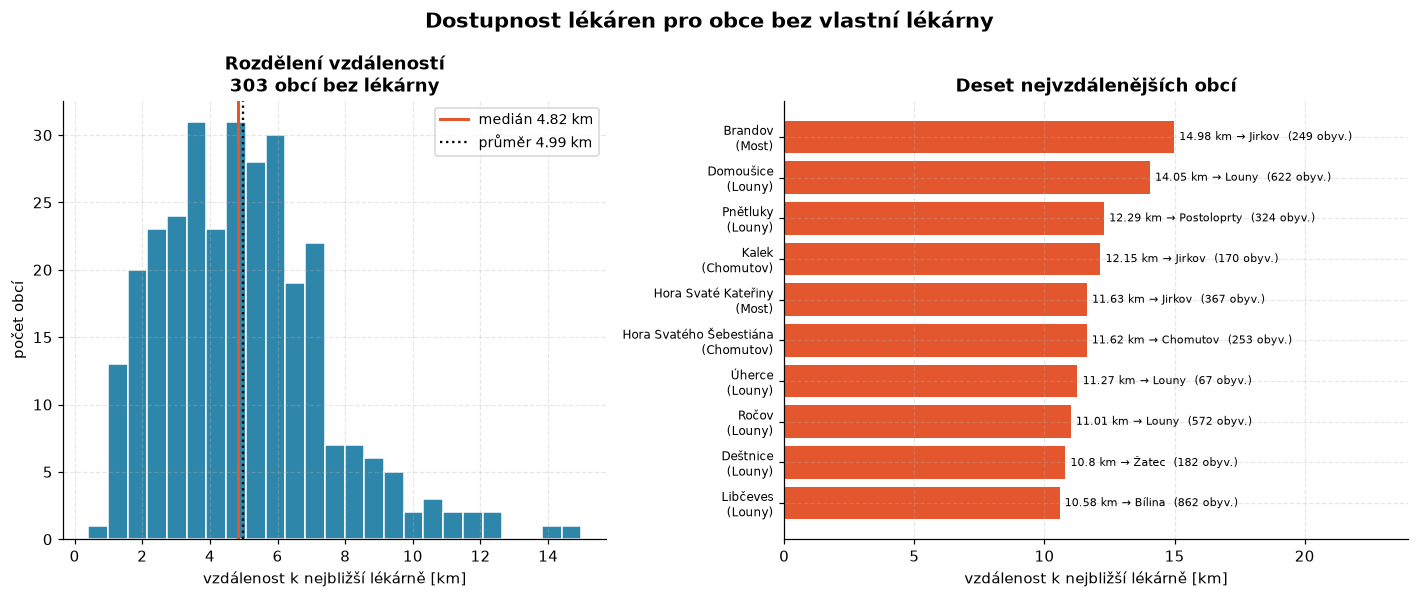

In [9]:
fig = viz.graf_vzdalenosti(db)

**Zjištění:**

- medián 4,82 km a průměr 4,99 km jsou téměř shodné → rozdělení je symetrické
- **140 obcí je dál než 5 km**, 12 obcí dál než 10 km
- **66 788 obyvatel** žije dál než 5 km od lékárny
- v top 10 je **šest obcí okresu Louny** — potvrzuje poměr 13 lékáren / 70 obcí
- Brandov, Kalek, Hora Svaté Kateřiny leží v **krušnohorském hřebeni**; přes
  hory nic není, takže nejbližší lékárnu mají všechny v Jirkově

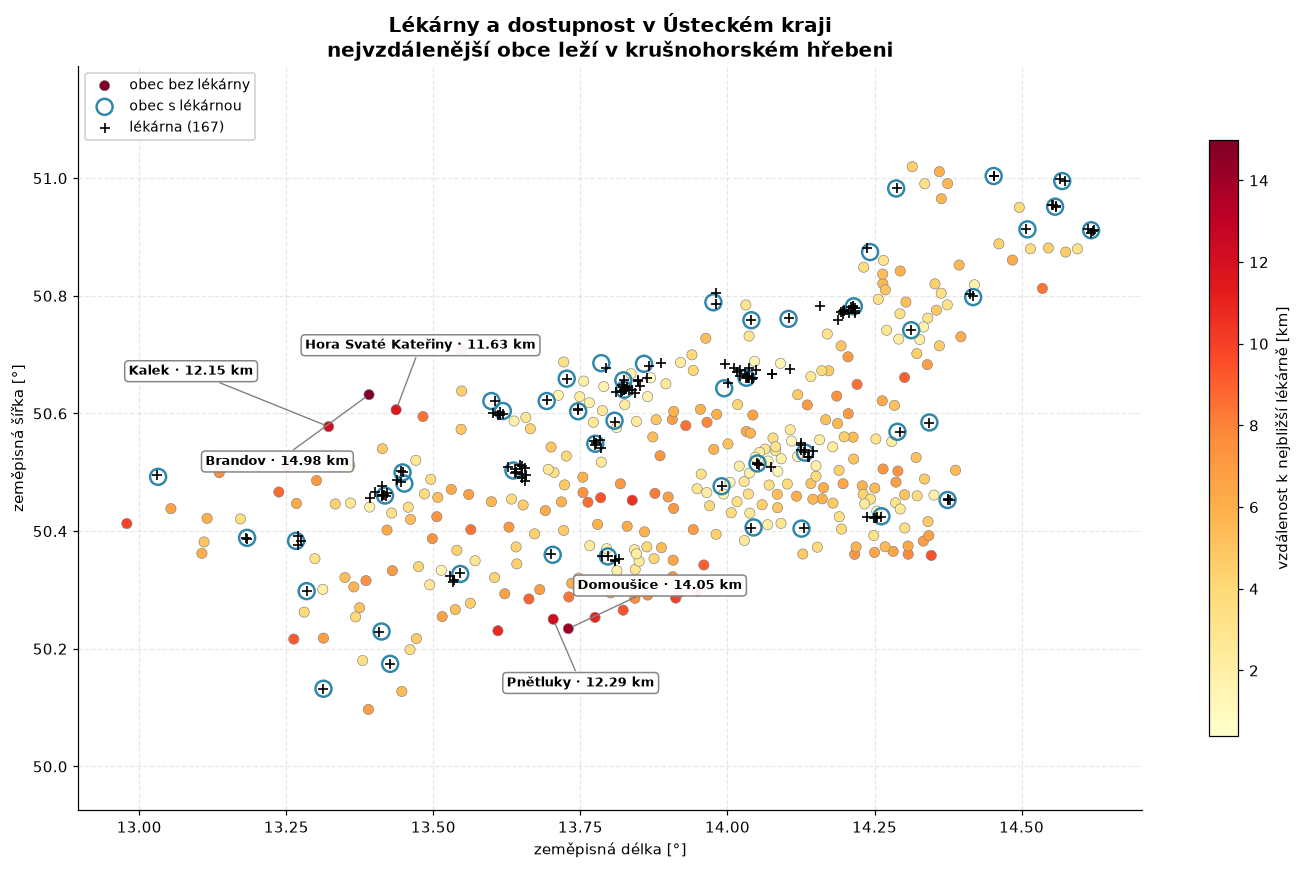

In [10]:
fig = viz.graf_mapa(db)

Mapa je zároveň **kontrolou správnosti souřadnic**: kdyby došlo k záměně
`[lng, lat]` (GeoJSON má obrácené pořadí proti běžnému čtení), body by ležely
mimo ČR. Tvar Ústeckého kraje je z rozložení obcí patrný.

## 4. Hlavní úloha (Neo4j): minimální kostra dostupnosti

Kostra je **nejlevnější podmnožina hran, která udrží graf spojitý** — tady
nejkratší možná síť spojnic, po níž je dosažitelná každá obec kraje.

### Model grafu

```
(:Obec)    -[:V_ORP]->     (:ORP)     -[:V_OKRESE]-> (:Okres) -[:V_KRAJI]-> (:Kraj)
(:Obec)    -[:V_OKRESE]->  (:Okres)                  ← zkratka, není redundantní
(:Lekarna) -[:V_OBCI]->    (:Obec)
(:Obec)    -[:BLIZKO {km}]-(:Obec)                   ← graf dostupnosti
```

Hrana `(:Obec)-[:V_OKRESE]->(:Okres)` **není redundantní** vůči cestě přes ORP:
hranice ORP a okresů se nekryjí, takže okres nelze odvodit průchodem.

`BLIZKO` je omezené na **6 nejbližších sousedů** místo úplného grafu
(62 481 hran). Hrany jsou symetrizované a spojitost se po vložení ověřuje —
kostra existuje jen nad spojitým grafem.

**Past v GDS:** `gds.spanningTree.stream` vrací i řádek pro **kořen** stromu,
kde `nodeId == parentId` a váha 0. Bez odfiltrování vyjde o hranu víc, než
strom může mít (*n* uzlů → *n*−1 hran).

In [11]:
drv = dn.pripoj()
g = dn.vytvor_projekci(drv)
print(f"projekce GDS: {g['nodeCount']} uzlů, {g['relationshipCount']} hran")

kostra = dn.kostra_souhrn(drv)
for k, v in kostra.items():
    print(f"{k:<14} {v}")

projekce GDS: 352 uzlů, 5064 hran
hran           351
celkem_km      986.53
prumer_km      2.81
nejkratsi_km   0.59
nejdelsi_km    7.7


In [12]:
pd.DataFrame(dn.kostra_hrany(drv, 10))

,obec,obec_ma_lekarnu,soused,soused_ma_lekarnu,km
0,Český Jiřetín,False,Klíny,False,7.70
1,Kalek,False,Boleboř,False,7.69
2,Kryštofovy Hamry,False,Vejprty,True,7.40
3,Lubenec,True,Blatno,False,6.71
4,Šluknov,True,Staré Křečany,False,6.66
5,Kytlice,False,Chřibská,False,6.44
6,Vejprty,True,Kovářská,False,6.21
7,Doubice,False,Jetřichovice,False,6.20
8,Deštnice,False,Holedeč,False,6.18
9,Horní Jiřetín,False,Litvínov,True,6.09


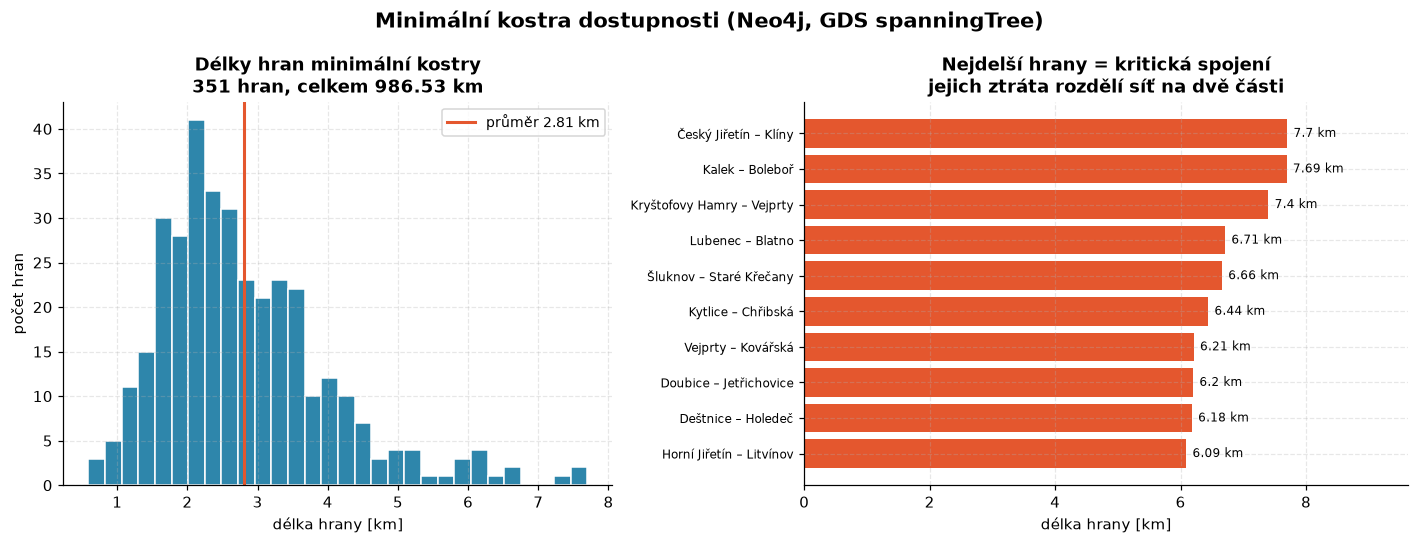

In [13]:
fig = viz.graf_kostra()

**Kostra: 351 hran, celkem 986,53 km, průměr 2,81 km.**

Všechna tři nejdelší spojení leží v **Krušných horách** (Český Jiřetín–Klíny
7,7 km, Kalek–Boleboř 7,69 km, Kryštofovy Hamry–Vejprty 7,4 km). Jsou to
**kritická spojení** — kdyby jedno vypadlo, síť se rozdělí na dva nespojené celky.

Hory jsou tak v obou analýzách ta samá překážka: objevují se jako nejdelší
hrany kostry i jako nejvzdálenější obce od lékáren.

## 5. Křížová validace obou modelů

Stejnou úlohu spočítám **oběma databázemi nezávisle** — Mongo přes
`$geoNear` s indexem `2dsphere`, Neo4j přes nativní `point.distance()`.

In [14]:
mongo_top = {r["obec"]: r["km"] for r in dm.nejvzdalenejsi_obce(db, 10)}
neo_top = {r["obec"]: r["km"] for r in dn.nejblizsi_lekarna(drv, 10)}

srovnani = pd.DataFrame([
    {"obec": o, "MongoDB [km]": mongo_top[o], "Neo4j [km]": neo_top.get(o),
     "rozdíl": round(abs(mongo_top[o] - neo_top[o]), 4) if o in neo_top else None}
    for o in mongo_top
])
srovnani

,obec,MongoDB [km],Neo4j [km],rozdíl
0,Brandov,14.98,14.98,0.0
1,Domoušice,14.05,14.05,0.0
2,Pnětluky,12.29,12.29,0.0
3,Kalek,12.15,12.15,0.0
4,Hora Svaté Kateřiny,11.63,11.63,0.0
5,Hora Svatého Šebestiána,11.62,11.62,0.0
6,Úherce,11.27,11.27,0.0
7,Ročov,11.01,11.01,0.0
8,Deštnice,10.80,10.80,0.0
9,Libčeves,10.58,10.58,0.0


**Shoda na dvě desetinná místa.** Dvě různé databáze, dvě různé
implementace geodetického výpočtu, stejný výsledek — důkaz, že data i výpočet
jsou správné. Kdyby se rozešly, byla by chyba v souřadnicích nebo v pořadí
`lat`/`lng`.

## 6. Vlastní zpracování

### 6.1 Lékárenská pustina — vážení počtem obyvatel

Samotná vzdálenost neříká, **kolika lidí** se problém týká.

In [15]:
pustina = pd.DataFrame(dm.lekarenska_pustina(db, 12))
pustina[["obec", "okres", "populace", "km", "osobokm", "lekarna_v"]]

,obec,okres,populace,km,osobokm,lekarna_v
0,Peruc,Louny,2109,9.09,19171.0,Libochovice
1,Chlumec,Ústí nad Labem,4170,4.06,16930.0,Krupka
2,Mikulášovice,Děčín,2375,5.63,13371.0,Dolní Poustevna
3,Bečov,Most,2072,5.98,12391.0,Most
4,Velký Šenov,Děčín,1978,5.69,11255.0,Šluknov
5,Lom,Most,3762,2.87,10797.0,Litvínov
6,Verneřice,Děčín,1083,9.00,9747.0,Benešov nad Ploučnicí
7,Horní Jiřetín,Most,1963,4.95,9717.0,Litvínov
8,Bohušovice nad Ohří,Litoměřice,2544,3.80,9667.0,Litoměřice
9,Horní Beřkovice,Litoměřice,989,9.49,9386.0,Roudnice nad Labem


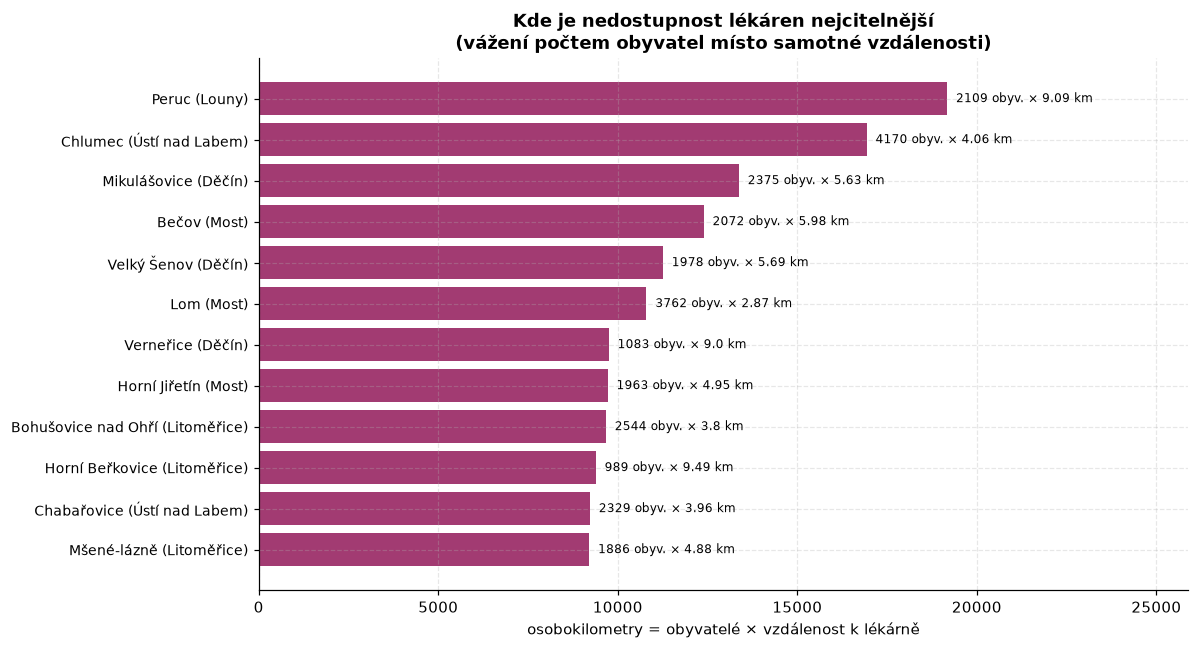

In [16]:
fig = viz.graf_pustina(db)

**Vážení populací přeskládá pořadí.** Brandov je nejdál (14,98 km), ale
žije tam 249 lidí. Chlumec je jen 4,06 km od lékárny, ale má 4 170 obyvatel —
v součtu je nedostupnost citelnější tam.

Kdyby kraj řešil, kde otevřít lékárnu, samotná vzdálenost by ho poslala do
Brandova ke 249 lidem; osobokilometry ukazují **Peruc a Chlumec**, kde je
dopad desetinásobný.

### 6.2 Koncentrace lékárenských sítí

In [17]:
for r in dm.retezce_po_okresech(db):
    rozpis = ", ".join(f"{x['retezec']} {x['pocet']}" for x in r["retezce"])
    print(f"{r['okres']:<16} celkem {r['celkem']:>3}   "
          f"největší podíl {r['nejvetsi_podil']:>5} %   {rozpis}")

Děčín            celkem  34   největší podíl  64.7 %   nezávislá 22, BENU 7, Dr. Max 5
Teplice          celkem  32   největší podíl  62.5 %   nezávislá 20, Dr. Max 8, BENU 4
Litoměřice       celkem  27   největší podíl  66.7 %   nezávislá 18, Dr. Max 7, BENU 2
Ústí nad Labem   celkem  23   největší podíl  65.2 %   nezávislá 15, Dr. Max 6, BENU 2
Chomutov         celkem  20   největší podíl  65.0 %   nezávislá 13, Dr. Max 6, BENU 1
Most             celkem  18   největší podíl  38.9 %   nezávislá 7, BENU 6, Dr. Max 5
Louny            celkem  13   největší podíl  53.8 %   nezávislá 7, Dr. Max 4, BENU 2


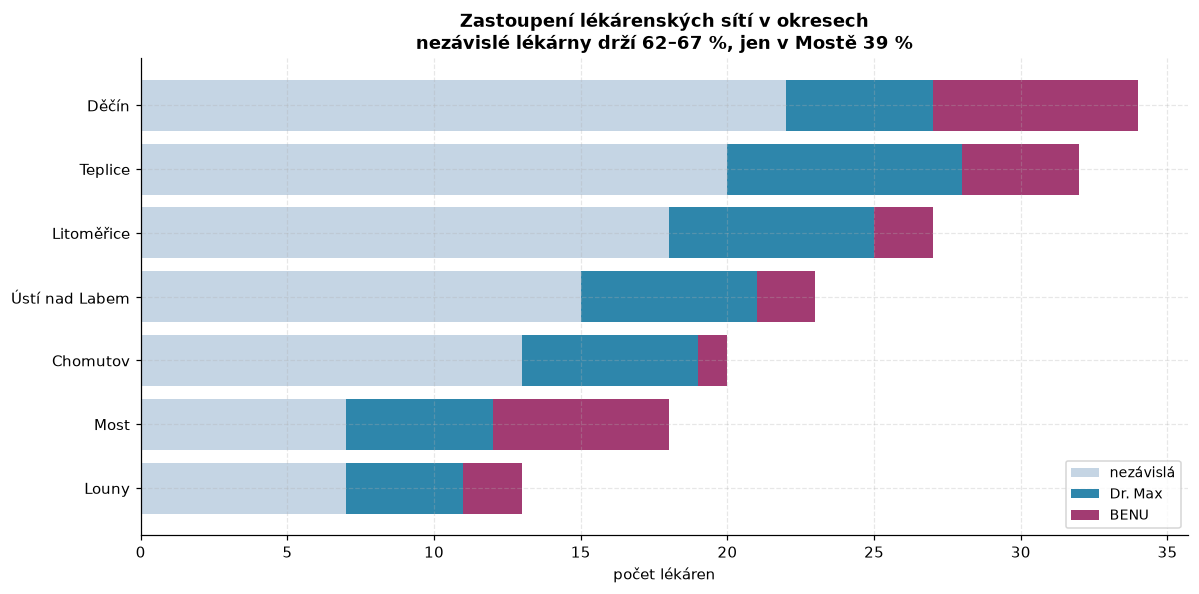

In [18]:
fig = viz.graf_retezce(db)

**Nezávislé lékárny drží 62–67 % ve všech okresech kromě Mostu**, kde je
trh rozdělený téměř na třetiny (nezávislé 39 %, BENU 33 %, Dr. Max 28 %).
To je proti běžné představě, že sítě český trh ovládly.

### 6.3 Hustota lékáren na obyvatele

In [19]:
pd.DataFrame(dm.obce_s_nejvic_lekarnami(db, 10))

,populace,lekaren,obec,okres,status,na_10tis
0,247,1,Hřensko,Děčín,obec,40.49
1,663,2,Petrovice,Ústí nad Labem,obec,30.17
2,558,1,Otvice,Chomutov,obec,17.92
3,1190,1,Radonice,Chomutov,obec,8.40
4,1240,1,Hostomice,Teplice,městys,8.06
5,1401,1,Liběšice,Litoměřice,obec,7.14
6,8744,6,Lovosice,Litoměřice,město,6.86
7,1541,1,Lubenec,Louny,obec,6.49
8,1723,1,Třebenice,Litoměřice,město,5.80
9,1772,1,Libouchec,Ústí nad Labem,obec,5.64


**Pozor na interpretaci poměrových ukazatelů na malém základu.** Vítěz
Hřensko má 40,5 lékáren na 10 tisíc obyvatel, tedy 1 lékárnu na 247 obyvatel —
ale je to turistické středisko u Pravčické brány, ne péče o místní. Podobně
Petrovice (30,2) leží na hraničním přechodu.

Věcně smysluplný je až **Lovosice: 6 lékáren na 8 744 obyvatel (6,86)**, což
je 3,6× víc než Most (1,9). Vysvětlení je poloha na D8 a spádovost okolních obcí.

### 6.4 Změny územní struktury 2013 → 2024

XLSX obsahuje 12 ročních řezů, takže územní změny jsou v datech zdarma.

In [20]:
from parse_uzemi import zmeny_prislusnosti

zm = zmeny_prislusnosti()
print(f"obcí v ČR {zm['rok_od']}: {zm['pocet_obci_od']}")
print(f"obcí v ČR {zm['rok_do']}: {zm['pocet_obci_do']}")
print(f"nových {len(zm['nove'])}, zaniklých {len(zm['zaniklé'])}, "
      f"přesunutých {len(zm['presunute'])}")

radky = []
for z in zm["presunute"]:
    for uroven, d in z["zmeny"].items():
        radky.append({"obec": z["obec_nazev"], "úroveň": uroven,
                      "z": f"{d['z']['nazev']} ({d['z']['kod']})",
                      "na": f"{d['na']['nazev']} ({d['na']['kod']})"})
pd.DataFrame(radky)

obcí v ČR 1.1.2013: 6253
obcí v ČR 1.1.2024: 6258
nových 6, zaniklých 1, přesunutých 19


,obec,úroveň,z,na
0,Bříství,orp,Český Brod (2106),Lysá nad Labem (2113)
1,Kounice,orp,Český Brod (2106),Lysá nad Labem (2113)
2,Vykáň,orp,Český Brod (2106),Lysá nad Labem (2113)
3,Študlov,okres,Vsetín (CZ0723),Zlín (CZ0724)
4,Valašské Příkazy,okres,Vsetín (CZ0723),Zlín (CZ0724)
5,Bukovec,okres,Domažlice (CZ0321),Plzeň-jih (CZ0324)
6,Holýšov,okres,Domažlice (CZ0321),Plzeň-jih (CZ0324)
7,Horní Kamenice,okres,Domažlice (CZ0321),Plzeň-jih (CZ0324)
8,Kvíčovice,okres,Domažlice (CZ0321),Plzeň-jih (CZ0324)
9,Neuměř,okres,Domažlice (CZ0321),Plzeň-jih (CZ0324)


**Územní příslušnost není v čase stabilní** — 19 obcí změnilo ORP nebo okres.
Kdyby se lékárny z roku 2026 spojily s hierarchií 2013, u těchto obcí by
vznikla chybná zařazení. Proto každý dokument nese `rok_listu`.

Šest nových obcí s kódy `5001xx` vzniklo **zrušením vojenských újezdů**
(Bražec, Doupovské Hradiště, Město Libavá, Polná na Šumavě); zaniklá obec
**Brdy** je opačný případ.

## 7. Ověření použití indexu

Zadání i hodnocení oceňují důkaz, že geodotaz **skutečně používá index**,
ne collection scan.

`explain()` se v pymongo na agregaci nedělá parametrem (vyhodí
`ConfigurationError`) — musí přes `db.command`.

In [21]:
obec = db.obce.find_one({"nazev": "Brandov"})
plan = db.command({
    "explain": {
        "aggregate": "lekarny",
        "pipeline": [
            {"$geoNear": {"near": obec["loc"], "distanceField": "d",
                          "spherical": True}},
            {"$limit": 3},
        ],
        "cursor": {},
    },
    "verbosity": "queryPlanner",
})

def najdi_indexy(o):
    out = []
    if isinstance(o, dict):
        if "indexName" in o:
            out.append((o.get("stage"), o["indexName"]))
        for v in o.values():
            out += najdi_indexy(v)
    elif isinstance(o, list):
        for v in o:
            out += najdi_indexy(v)
    return out

print("stupně plánu využívající index:", najdi_indexy(plan))
print("\nindexy kolekce lekarny:", sorted(db.lekarny.index_information()))
print("indexy kolekce obce:   ", sorted(db.obce.index_information()))

stupně plánu využívající index: [('GEO_NEAR_2DSPHERE', 'lekarny_loc_2dsphere')]

indexy kolekce lekarny: ['_id_', 'lekarny_loc_2dsphere', 'lekarny_obec', 'lekarny_okres', 'lekarny_orp', 'lekarny_retezec']
indexy kolekce obce:    ['_id_', 'obce_loc_2dsphere', 'obce_ma_lekarnu', 'obce_nazev_norm', 'obce_okres', 'obce_orp']


Plán obsahuje stupeň **`GEO_NEAR_2DSPHERE`** s indexem
`lekarny_loc_2dsphere` → žádný collection scan. Bez `2dsphere` indexu by
MongoDB geodotaz vůbec neprovedlo.

## 8. Ověření schéma validace

MongoDB je schemaless, ale `$jsonSchema` umí kontrolovat zápisy. Validátory
jsou připojené k oběma kolekcím — ukazuje to, že volba „bez schématu" je
**rozhodnutí, ne neznalost**.

In [22]:
try:
    db.obce.insert_one({"_id": "TEST", "nazev": "Vadná obec"})
    print("CHYBA: vadný dokument prošel!")
except Exception as e:
    print(f"OK — zápis bez povinných polí odmítnut: {type(e).__name__}")
    print(f"   {str(e)[:160]}")

OK — zápis bez povinných polí odmítnut: WriteError
   Document failed validation, full error: {'index': 0, 'code': 121, 'errmsg': 'Document failed validation', 'errInfo': {'failingDocumentId': 'TEST', 'details': {'


In [23]:
drv.close()
print("hotovo")

hotovo
